# Electricity Demand Forecasting using AI

Before running this notebook, please make sure you installed the requiremented packages and libraries. For more detailled explaination about why we included certain data in the dataset or choose certain models, please take a lot in the project report which you can find in the `docs/` folder. 

Since some feature values are missing, a `MissingValuesWarning` is raised. This warning cannot be suppressed when using the `xgbboost` library. To avoid unnecessary clutter, the outputs shown on GitHub have been cleared for the purpose of our explanations.

In [1]:
import time
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap
import warnings
from skforecast.exceptions import MissingValuesWarning, LongTrainingWarning

from core.create_dataset import create_dataset
from core.grafical_exploration import *

warnings.simplefilter('ignore', category=MissingValuesWarning)
warnings.simplefilter('ignore', category=LongTrainingWarning)

Here, you can define all parameters used for model training and backtesting. The Dataset is split into 90% training and 10% testing. The selected `eval_metric` is shown in the plots. You can change it as needed. If you choose a different metric, you can look it up in the [Skforecast documentation](https://skforecast.org/0.15.0/user_guides/metrics) and add it to the `metrics` list of available metrics. 

`lags` defines the number of recent past values the model gets as an input. Rolling window features `window_features` are used to provide the model with historical context by summarizing most recent past observations over fixed time windows.

In [2]:
start = '2015-01-01'
train_end = '2023-12-31'
test_end = '2024-12-31'
eval_metric = 'mean_absolute_percentage_error'
metrics = ['mean_absolute_error', 'mean_squared_error', 'mean_absolute_percentage_error']
lags = 24
window_features = RollingFeatures(stats=['mean', 'std', 'min', 'max'], window_sizes=[24*3, 24*7, 24*7, 24*7])

### Dataset Creation

Now, we need to create a dataset that can be used to train the model. We are using different APIs, such as `smard-api` and `digidates`, which are slow when fetching a lot of data over a long period of time due to their API design. Therefore, we have commented out the `create_dataset()` function and loaded the dataset directly instead.

In [3]:
# # create dataset
# df = create_dataset()

# load dataset
df = pd.read_csv('dataset.csv', delimiter=';')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df_plot = df.copy()
df = df.set_index('datetime').sort_index()
data = df.copy()
data_train = data.loc[start:train_end].asfreq('h') # explicity annotate frequency is hourly
prediction_results, metrics_results = pd.DataFrame(), pd.DataFrame()
prediction_results['actual_grid_load'] = data['grid_load'].loc[pd.to_datetime(train_end, utc=True)+pd.Timedelta(days=1):pd.to_datetime(test_end, utc=True)]

At the beginning of the analysis, several exploratory plots are generated to gain an initial understanding of the data. These visualizations highlight long-term trends, recurring seasonal patterns, and typical daily load profiles, forming the basis for subsequent modeling decisions such as lag selection, seasonality assumptions, and baseline definition.

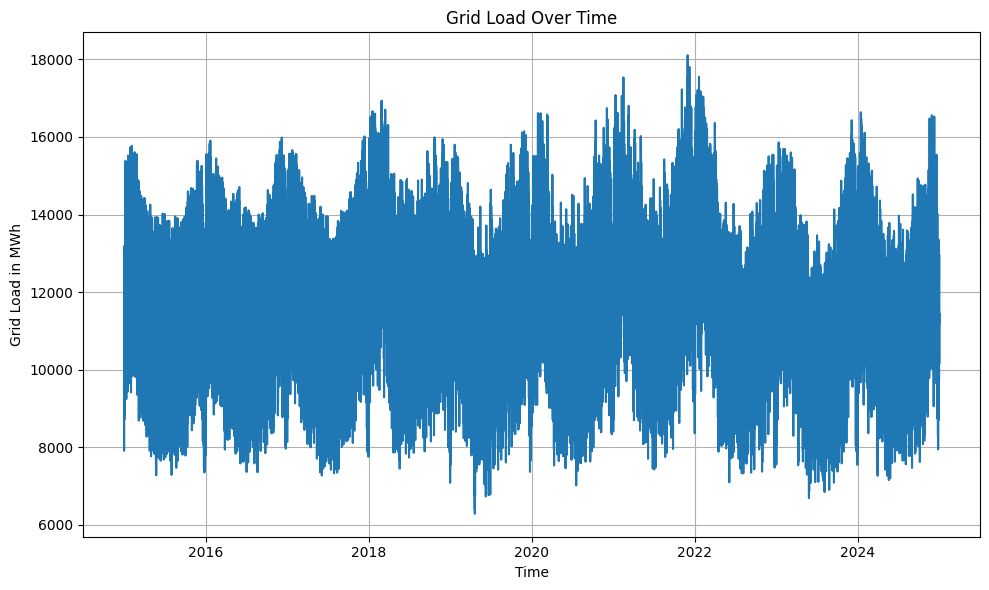

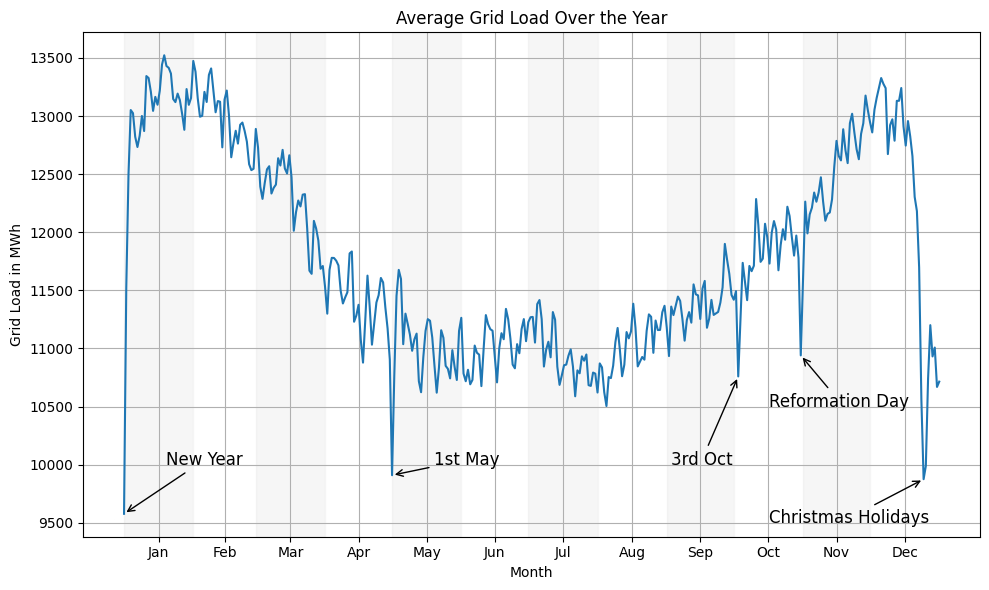

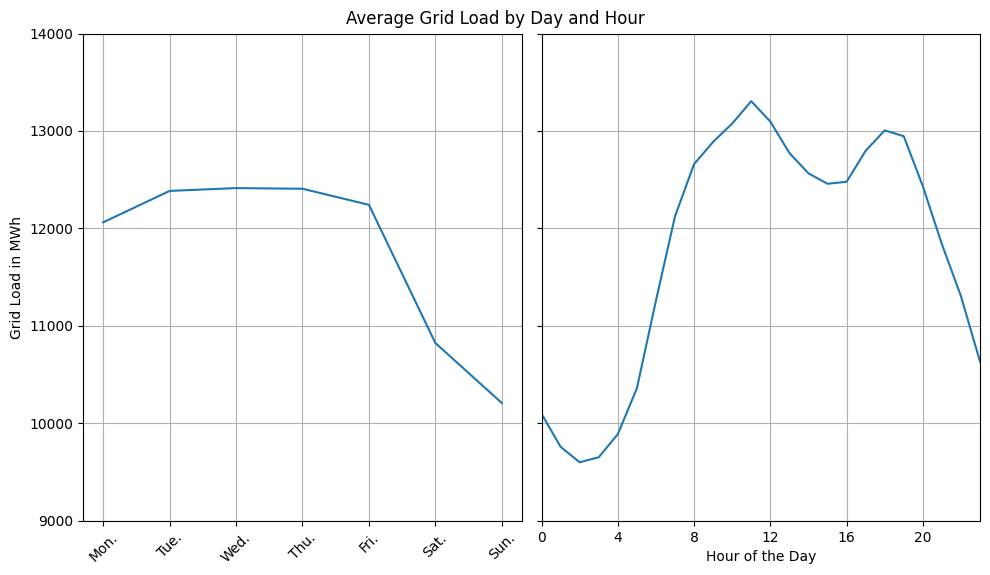

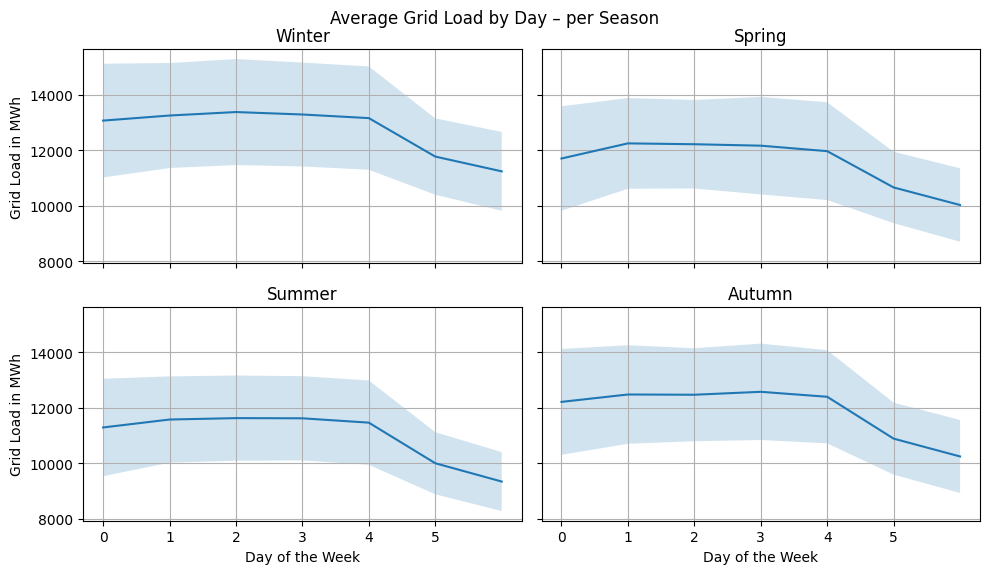

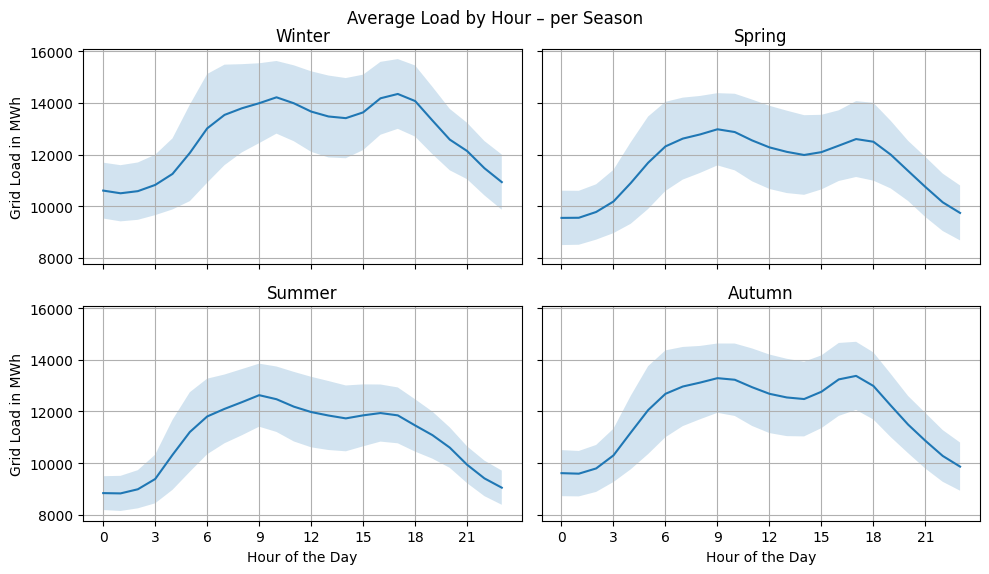

In [4]:
plot_grid_load(df_plot)
plot_average_year(df_plot)
plot_average_day_hour(df_plot)
plot_average_load_by_day_and_season(df_plot)
plot_average_load_by_hour_and_season(df_plot)

### Model Selection

Conventional cross-validation does not make sense for time series data since the order of the values is important. Therefore, we use a TimeSeriesFold to test our data on new data that our model has not been trained on. Moreover, we start by turning off the `refit` option, since refitting our model 365/366 times for backtesting is computationally very expensive. We test the model's performance over a year and calculate the average error, but only display one week in the plot. This can be changed when calling the `plot_predictions()` function.

In [5]:
def plot_predictions(df, predictions, model_name, eval_metric, metric, start_plot='2024-03-04', end_plot='2024-03-11'):
    start_plot = pd.Timestamp(start_plot)
    end_plot = pd.Timestamp(end_plot)
    val_week = df['grid_load'].loc[predictions.index.min():predictions.index.max()]
    fig, ax = plt.subplots(figsize=(10,6))
    val_week.plot(ax=ax, label='Actual Load', color='tab:blue')
    predictions['pred'].plot(ax=ax, label='Forecast', color='tab:red')
    plt.xlim(start_plot, end_plot)
    plt.ylabel("Grid Load in MWh")
    plt.xlabel("")
    if eval_metric == 'mean_absolute_percentage_error':
        plt.title(f"{model_name} with MAPE {metric*100:.2f}% ")
    elif eval_metric == 'mean_squared_error':
        plt.title(f"{model_name} with MSE {metric:.2f} (MWh)^2 ")
    elif eval_metric == 'mean_absolute_error':
        plt.title(f"{model_name} with MAE {metric:.2f} MWh ")
    plt.grid()
    plt.legend(loc = 'upper right')
    plt.tight_layout()
    plt.show()

def backtesting(model, df, cv, test_end, metrics, exog=False):
    metric, predictions = backtesting_forecaster(
                                forecaster = model,
                                y = df.loc['2015-01-01':test_end]['grid_load'].asfreq('h'),
                                exog = df.loc['2015-01-01':test_end].drop(columns=['grid_load']) if exog else None,
                                cv = cv,
                                metric = metrics)
    return metric, predictions

# define cross-validation scheme
cv = TimeSeriesFold(steps=24, initial_train_size=len(data_train), refit=False)

When addressing a forecasting task, it is essential to first define a baseline model. A baseline serves as a simple reference, allowing the performance of more advanced models to be evaluated in a meaningful way. This approach, often referred to as seasonal naive forecasting, predicts future values by reusing observations from the same point in a previous season—for example, the same weekday of the previous week or the same hour of the previous day. Based on the results of the exploratory data analysis, the baseline model forecasts each hour using the value observed at the corresponding hour on the previous day.

  0%|          | 0/366 [00:00<?, ?it/s]

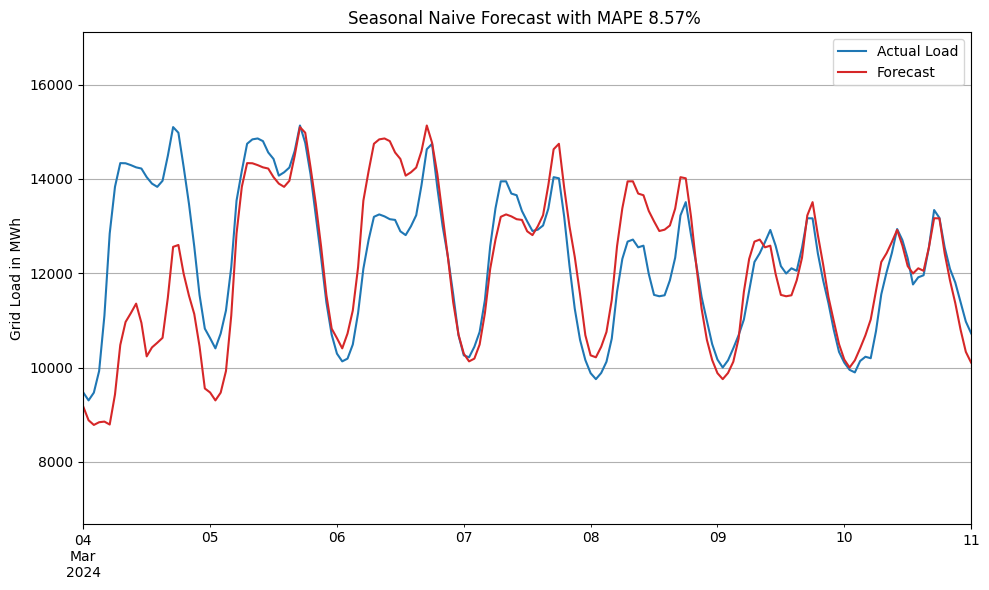

In [6]:
# seasonal naive baseline
model_baseline = ForecasterEquivalentDate(offset=pd.DateOffset(days=1), n_offsets=1)
metric, predictions = backtesting(model_baseline, data, cv, test_end, metrics)
plot_predictions(data, predictions, "Seasonal Naive Forecast", eval_metric, metric[eval_metric].values[0])

# store results
prediction_results['seasonal_naive_forecast'] = predictions['pred']
row = { "model_name": "seasonal_naive_forecast",
        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
metrics_results = pd.concat([pd.DataFrame([row]), metrics_results], ignore_index=True).drop_duplicates()

When working with time series data, it is rarely sufficient to predict only the next single value $(t+1)$. In most practical applications, the objective is to forecast an entire future interval $(t+1, \dots, t+n)$ or a specific point further ahead in time $(t+n)$. Several strategies exist to address this type of multi-step forecasting problem. Two commonly used forecasters are `ForecasterRecursive` and `ForecasterDirect`. Both approaches have advantages and trade-offs. While the direct strategy can provide more accurate long-horizon forecasts, it comes at the cost of significantly increased computational effort, as a separate model must be trained for each forecast step.

To assess whether a recursive forecasting strategy is suitable in our setting, it is useful to analyze the autocorrelation structure of the time series. The autocorrelation plot reveals a clear periodic pattern, indicating strong temporal dependencies across lags. This observation suggests that a recursive forecasting approach is well-suited for this problem.

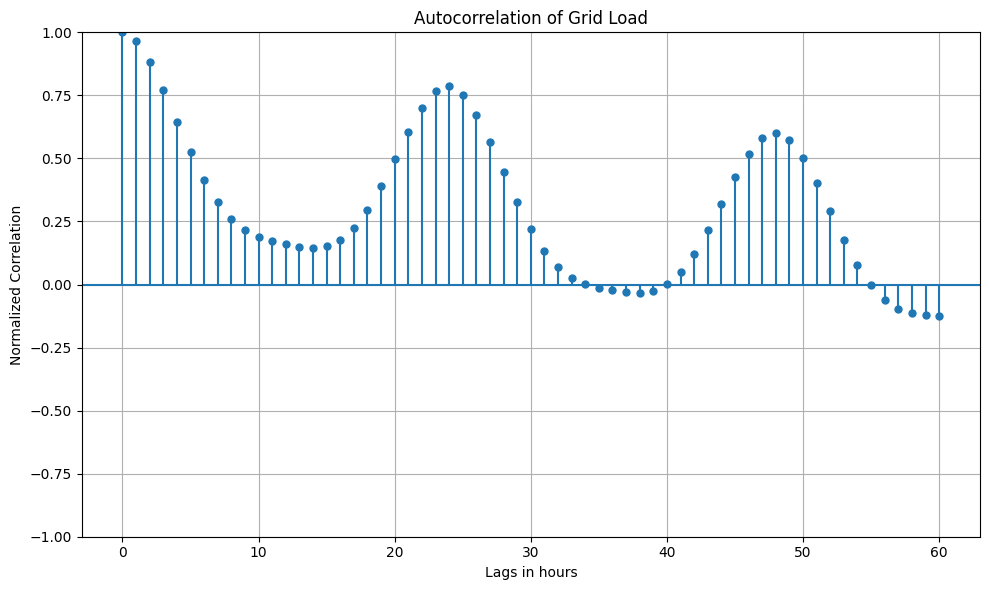

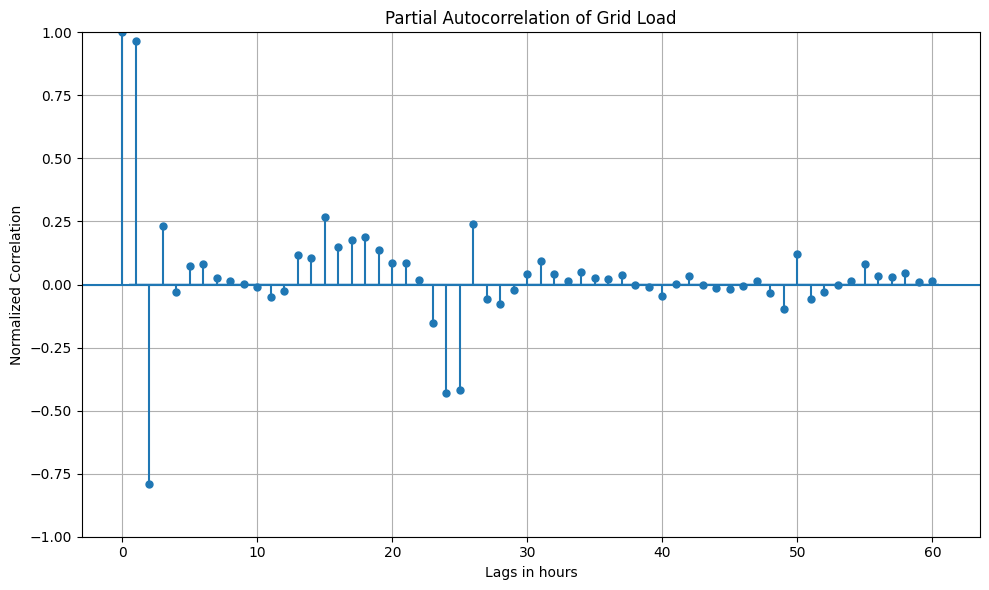

In [7]:
plot_autocorrelation(df_plot)

To determine the most suitable estimator for use within the forecaster, several models are evaluated, including linear approaches such as Ridge regression and tree-based models. The Ridge model requires a complete feature matrix without missing values, an assumption that cannot be guaranteed when incorporating exogenous variables. For this reason, it is excluded from further consideration.

After establishing the baseline, a recursive `XGBRegressor` and `LGBMRegressor` without exogenous features are introduced as a more expressive reference model. In this setup, the regressor is trained exclusively on lagged values of the target variable, enabling it to capture nonlinear temporal dependencies inherent in the series without relying on external inputs. Forecasts are generated recursively: the model predicts the next time step based on the available history, and each prediction is fed back into the input sequence to iteratively produce forecasts over the full prediction horizon. Among the tree-based models, both show comparable performance when trained solely on the target time series without exogenous features, with XGBoost exhibiting a slight advantage. Consequently, both models are retained for further experimentation, and the final selection is based on empirical performance.

In [8]:
# recursive lgbm/xgb without exogenous features
estimators = [XGBRegressor(random_state=123, verbosity=0),
              LGBMRegressor(random_state=123, verbose=-1)]

for estimator in estimators:
    estimator_name = estimator.__class__.__name__
    print(f"Fitting and backtesting: {estimator_name}")
    forecaster = ForecasterRecursive(estimator = estimator,
                                lags = 168,
                                window_features = window_features)

    metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=False)
    # save results
    prediction_results[estimator_name + ' without exogenous features'] = predictions['pred']
    row = { "model_name": estimator_name + ' without exogenous features',
            "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
            "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
            "mean_squared_error": metric["mean_squared_error"].iloc[0]}
    metrics_results = pd.concat([pd.DataFrame([row]), metrics_results], ignore_index=True).drop_duplicates()

Fitting and backtesting: XGBRegressor


  0%|          | 0/366 [00:00<?, ?it/s]

Fitting and backtesting: LGBMRegressor


  0%|          | 0/366 [00:00<?, ?it/s]

In [9]:
mape_xgbm = metrics_results.set_index("model_name").loc["XGBRegressor without exogenous features", "mean_absolute_percentage_error"]
mape_lgbm = metrics_results.set_index("model_name").loc["LGBMRegressor without exogenous features", "mean_absolute_percentage_error"]

print(f"XGBRegressor without exogenous features MAPE: {mape_xgbm*100:.2f}%")
print(f"LGBMRegressor without exogenous features MAPE: {mape_lgbm*100:.2f}%")

XGBRegressor without exogenous features MAPE: 5.38%
LGBMRegressor without exogenous features MAPE: 5.17%


As a next step, the recursive model is extended by incorporating exogenous features, enabling the model to account not only for the internal dynamics of the time series but also for external factors that systematically influence the target variable.

In [ ]:
# recursive lgbm/xgb without exogenous features
for estimator in estimators:
    estimator_name = estimator.__class__.__name__
    print(f"Fitting and backtesting: {estimator_name}")
    forecaster = ForecasterRecursive(estimator = estimator,
                                lags = 168,
                                window_features = window_features)
    metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=True)
    
    # save results
    prediction_results[estimator_name + ' with exogenous features'] = predictions['pred']
    row = { "model_name": estimator_name + ' with exogenous features',
            "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
            "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
            "mean_squared_error": metric["mean_squared_error"].iloc[0]}
    metrics_results = pd.concat([pd.DataFrame([row]), metrics_results], ignore_index=True).drop_duplicates()

In [11]:
mape_xgbm = metrics_results.set_index("model_name").loc["XGBRegressor with exogenous features", "mean_absolute_percentage_error"]
mape_lgbm = metrics_results.set_index("model_name").loc["LGBMRegressor with exogenous features", "mean_absolute_percentage_error"]

print(f"XGBRegressor with exogenous features MAPE: {mape_xgbm*100:.2f}%")
print(f"LGBMRegressor with exogenous features MAPE: {mape_lgbm*100:.2f}%")

XGBRegressor with exogenous features MAPE: 3.66%
LGBMRegressor with exogenous features MAPE: 3.71%


### Tuning

Introducing exogenous variables improved our results. Initially, the model was trained using default hyperparameters and a fixed lag configuration (24 lags). However, there is no guarantee that these settings are optimal for our dataset.

As shown in the plot below, model performance does not follow a simple rule such as “more lags always leads to better results”. Manually experimenting with lag choices and hyperparameters would be extremely time-consuming and inefficient. Likewise, a brute-force approach such as grid search—testing every possible parameter combination within a predefined search space—is not feasible given the computational resources available.

For this reason, we apply Bayesian hyperparameter optimization, which explores the parameter space more efficiently by using past evaluations to decide which configurations to try next. This results in a model configuration that better balances bias and variance and typically improves predictive performance compared to default settings.

To tune the model, run the script `tuning.py`.

In [ ]:
lags = [24, 72, 168]
metrics_results_lags = pd.DataFrame()
for lag in lags:
    for estimator in estimators:
        for exog in [False, True]:
                estimator_name = estimator.__class__.__name__
                print(f"Fitting and backtesting: {estimator_name}")
                forecaster = ForecasterRecursive(estimator = estimator,
                                        lags = lag,
                                        window_features = window_features)
                metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=exog)
                
                # save results
                row = { "model_name": str(lag) + ": " + estimator_name + (' with exogenous features' if exog else ' without exogenous features'),
                        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
                        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
                        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
                metrics_results_lags = pd.concat([pd.DataFrame([row]), metrics_results_lags], ignore_index=True).drop_duplicates()

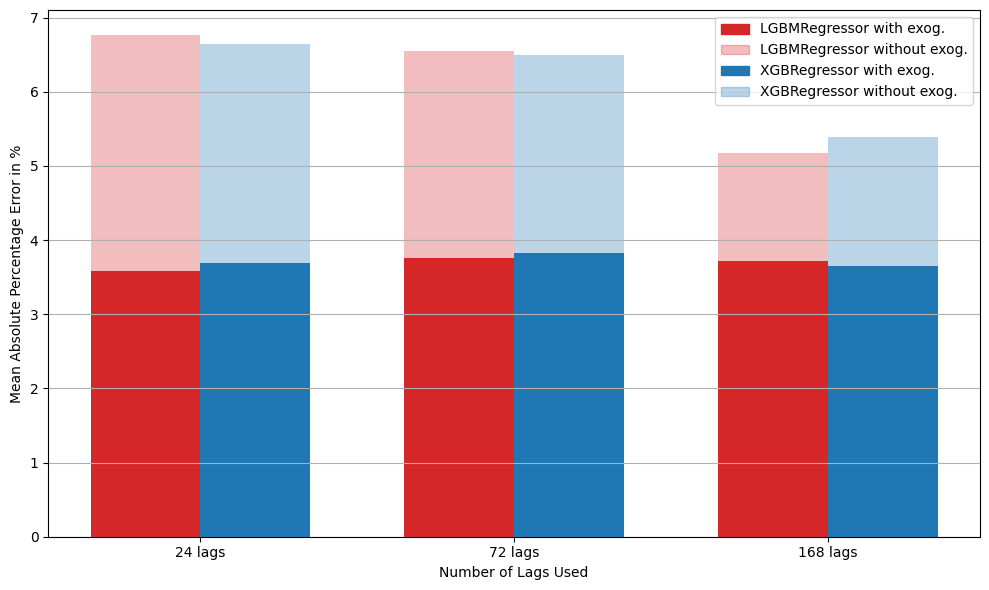

In [13]:
plt.figure(figsize=(10,6))
def get_base_name(name):
    return name.replace(" with exogenous features", "").replace(" without exogenous features", "")
lag_order = ['24', '72', '168']
model_types = ['LGBMRegressor', 'XGBRegressor']
bar_width = 0.35

for lag_idx, lag in enumerate(lag_order):
    for model_idx, model in enumerate(model_types):
        base_name = f"{lag}: {model}"
        subset = metrics_results_lags[metrics_results_lags["model_name"].apply(get_base_name) == base_name]
        color = 'tab:blue' if 'xgb' in model.lower() else 'tab:red'
        x_pos = lag_idx + (model_idx - 0.5) * bar_width
        for _, row in subset.iterrows():
            alpha = 1.0 if 'with exogenous features' in row["model_name"].lower() else 0.3
            mape = row["mean_absolute_percentage_error"] * 100
            plt.bar(x_pos, mape, color=color, alpha=alpha, width=bar_width)

plt.xticks(range(len(lag_order)), [f"{lag} lags" for lag in lag_order])
plt.xlabel("Number of Lags Used")
plt.ylabel("Mean Absolute Percentage Error in %")
plt.grid(axis='y')
legend_handles = [
    mpatches.Patch(color='tab:red', alpha=1.0, label='LGBMRegressor with exog.'),
    mpatches.Patch(color='tab:red', alpha=0.3, label='LGBMRegressor without exog.'),
    mpatches.Patch(color='tab:blue', alpha=1.0, label='XGBRegressor with exog.'),
    mpatches.Patch(color='tab:blue', alpha=0.3, label='XGBRegressor without exog.'),]
plt.legend(handles=legend_handles, loc='upper right')
plt.tight_layout()
plt.show()

Here we can see how tuning with our Baysian optimization reduces the error with every trial.

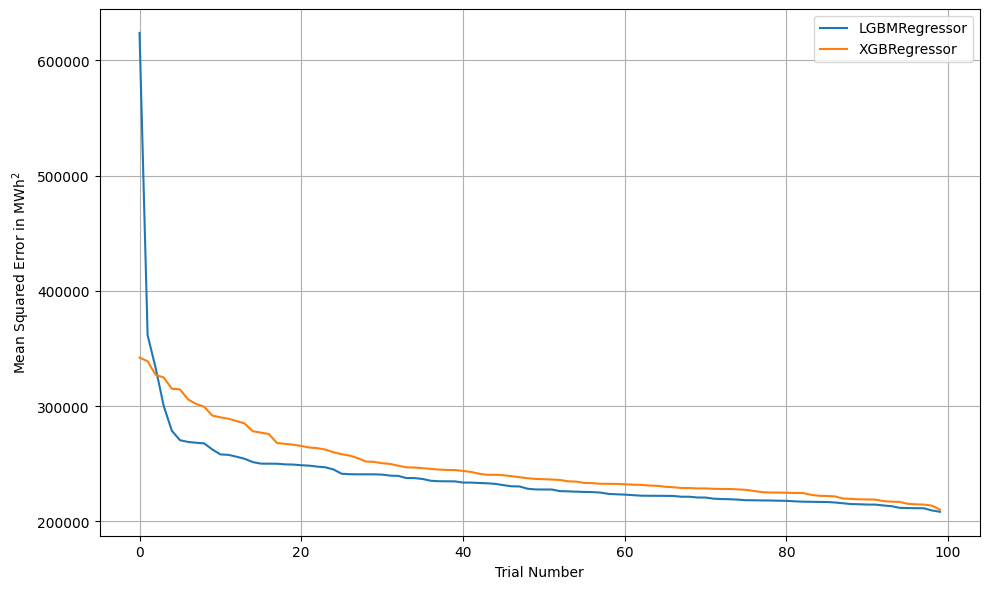

In [14]:
tuning_results_lgbm = pd.read_csv('results/tuning/LGBMRegressor_tuning.csv')
tuning_results_xgb = pd.read_csv('results/tuning/XGBRegressor_tuning.csv')
tuning_results_lgbm = tuning_results_lgbm.iloc[::-1].reset_index(drop=True)
tuning_results_xgb = tuning_results_xgb.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(tuning_results_lgbm.index, tuning_results_lgbm['mean_squared_error'], label='LGBMRegressor')
plt.plot(tuning_results_xgb.index, tuning_results_xgb['mean_squared_error'], label='XGBRegressor')
plt.xlabel("Trial Number")
plt.ylabel(r"Mean Squared Error in MWh$^2$")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

Here we use the resulting parameters of our tuning script and indeed the performance increased.

In [ ]:
# tuned recursive lgbm with exogenous features
best_params_lgbm = tuning_results_lgbm.iloc[-1]
best_params_xgb = tuning_results_xgb.iloc[-1]
params_lgbm = ast.literal_eval(best_params_lgbm['params'])
params_xgb = ast.literal_eval(best_params_xgb['params'])
best_lags_lgbm = list(map(int, best_params_lgbm['lags'].strip("[]").split()))
best_lags_xgb = list(map(int, best_params_xgb['lags'].strip("[]").split()))
    
tuned_estimators = [LGBMRegressor(**params_lgbm), XGBRegressor(**params_xgb)]

for estimator in tuned_estimators:
    estimator_name = estimator.__class__.__name__
    print(f"Fitting and backtesting: {estimator_name}")
    if estimator_name == "LGBMRegressor":
        lags = best_lags_lgbm
    else:
        lags = best_lags_xgb
    forecaster = ForecasterRecursive(estimator=estimator, lags=lags, window_features=window_features)
    metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=True)

    # store results
    prediction_results['Tuned ' + estimator_name + ' with exogenous features'] = predictions['pred']
    row = { "model_name": "Tuned " + estimator_name + " with exogenous features",
            "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
            "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
            "mean_squared_error": metric["mean_squared_error"].iloc[0]}
    metrics_results = pd.concat([metrics_results, pd.DataFrame([row])], ignore_index=True).drop_duplicates()

In [16]:
mape_xgbm = metrics_results.set_index("model_name").loc["Tuned XGBRegressor with exogenous features", "mean_absolute_percentage_error"]
mape_lgbm = metrics_results.set_index("model_name").loc["Tuned LGBMRegressor with exogenous features", "mean_absolute_percentage_error"]

print(f"XGBRegressor with exogenous features MAPE: {mape_xgbm*100:.2f}%")
print(f"LGBMRegressor with exogenous features MAPE: {mape_lgbm*100:.2f}%")

XGBRegressor with exogenous features MAPE: 3.15%
LGBMRegressor with exogenous features MAPE: 3.16%


### Final Model

In this backtesting setup, `refit=True` is used, meaning the model is retrained at each forecasting step using all data available up to that point. This differs from standard cross-validation, where the model is typically trained once per fold on randomly sampled data.

Here, the training window grows sequentially while preserving the temporal order of the time series. As a result, the model is repeatedly fitted on increasingly larger historical datasets before generating predictions, yielding a more realistic evaluation of forecasting performance at the cost of substantially increased computational time and CPU load (3:16h, Dell).

  0%|          | 0/366 [00:00<?, ?it/s]

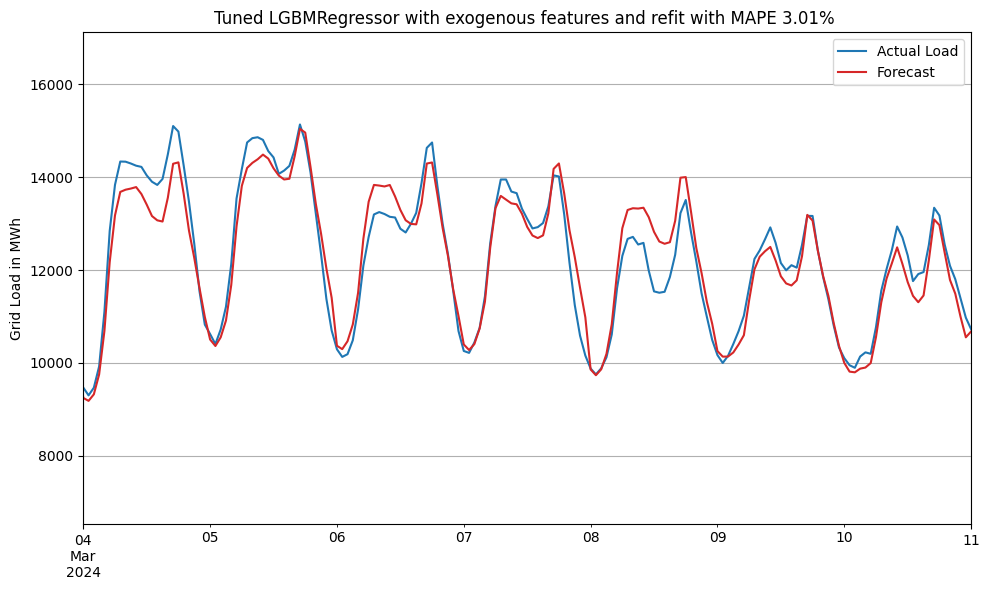

In [18]:
# tuned recursive lgbm with exogenous features and refit
start_time = time.time()
cv = TimeSeriesFold(steps=24, initial_train_size=len(data_train), refit=True)
estimator_lgbm = tuned_estimators[0]
forecaster_lgbm = ForecasterRecursive(estimator=estimator_lgbm, lags=best_lags_lgbm, window_features=window_features)
metric, predictions = backtesting(forecaster_lgbm, data, cv, test_end, metrics, exog=True)
end_time = time.time()
plot_predictions(data, predictions, "Tuned LGBMRegressor with exogenous features and refit", eval_metric, metric[eval_metric].values[0])
prediction_results['Tuned LGBMRegressor with exogenous features and refit'] = predictions['pred']
row = { "model_name": "Tuned LGBMRegressor with exogenous features and refit",
            "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
            "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
            "mean_squared_error": metric["mean_squared_error"].iloc[0]}
metrics_results = pd.concat([metrics_results, pd.DataFrame([row])], ignore_index=True).drop_duplicates()

In [19]:
print(f"Tuned LGBM with exogenous features and refit MAPE: {metric['mean_absolute_percentage_error'].values[0]*100:.2f}%")
print(f"Time taken for tuned recursive LGBM with exogenous features and refit: {end_time - start_time:.2f} seconds")

Tuned LGBM with exogenous features and refit MAPE: 3.01%
Time taken for tuned recursive LGBM with exogenous features and refit: 10430.06 seconds


In [ ]:
start_time = time.time()
lags = list(range(1,25)) + [167, 168, 169]
estimator_xgb = tuned_estimators[1]
forecaster_xgb = ForecasterRecursive(estimator=estimator_xgb, lags=best_lags_xgb, window_features=window_features)
metric, predictions = backtesting(forecaster_xgb, data, cv, test_end, metrics, exog=True)
end_time = time.time()

prediction_results['Tuned XGBRegressor with exogenous features with refit'] = predictions['pred']
row = { "model_name": "Tuned XGBRegressor with exogenous features with refit",
            "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
            "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
            "mean_squared_error": metric["mean_squared_error"].iloc[0]}
metrics_results = pd.concat([metrics_results, pd.DataFrame([row])], ignore_index=True).drop_duplicates()

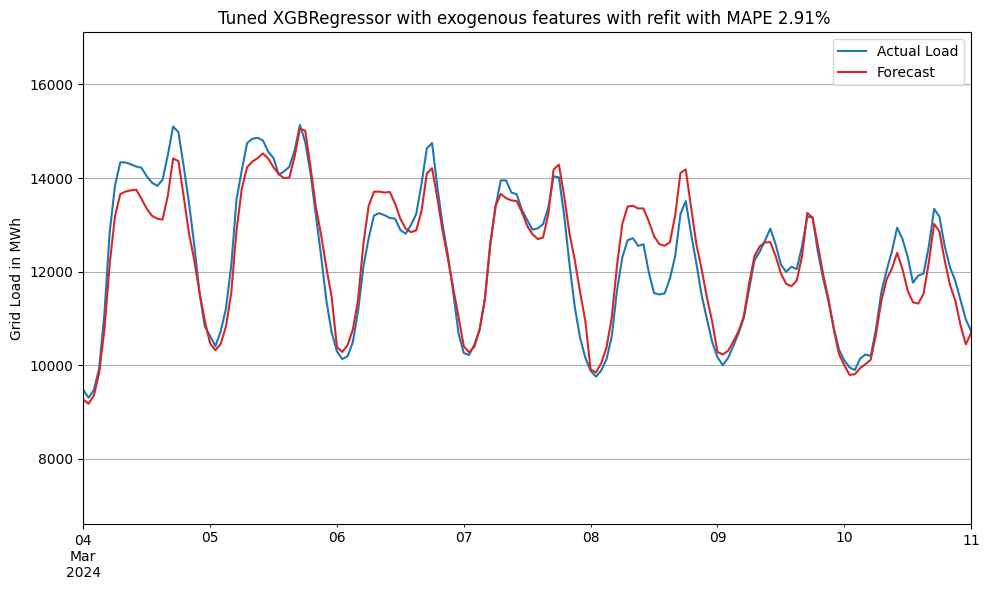

Tuned XGB with exogenous features and refit MAPE: 2.91%
Time taken for tuned recursive XGB with exogenous features and refit: 2473.84 seconds


In [26]:
plot_predictions(data, predictions, "Tuned XGBRegressor with exogenous features with refit", eval_metric, metric[eval_metric].values[0])
print(f"Tuned XGB with exogenous features and refit MAPE: {metric['mean_absolute_percentage_error'].values[0]*100:.2f}%")
print(f"Time taken for tuned recursive XGB with exogenous features and refit: {end_time - start_time:.2f} seconds")

### Explain Model

To explain a model, different techniques from the XAI toolkit can be applied, ranging from simple feature importance measures to more advanced methods such as ICE plots or SHAP values. In this project, we focus on feature importances and SHAP values to better understand which inputs drive the model’s predictions.

In addition, we perform a sequential feature addition analysis to quantify how much each feature contributes to error reduction in practice. This helps distinguish features that are merely correlated from those that provide meaningful predictive value.

All explanation steps are implemented in a separate script called `explain.py`. Running it can take some time: computing feature importances is relatively cheap because it typically requires only a single model fit, whereas the sequential feature analysis is significantly more computationally intensive since the model must be retrained every time a new feature is added.

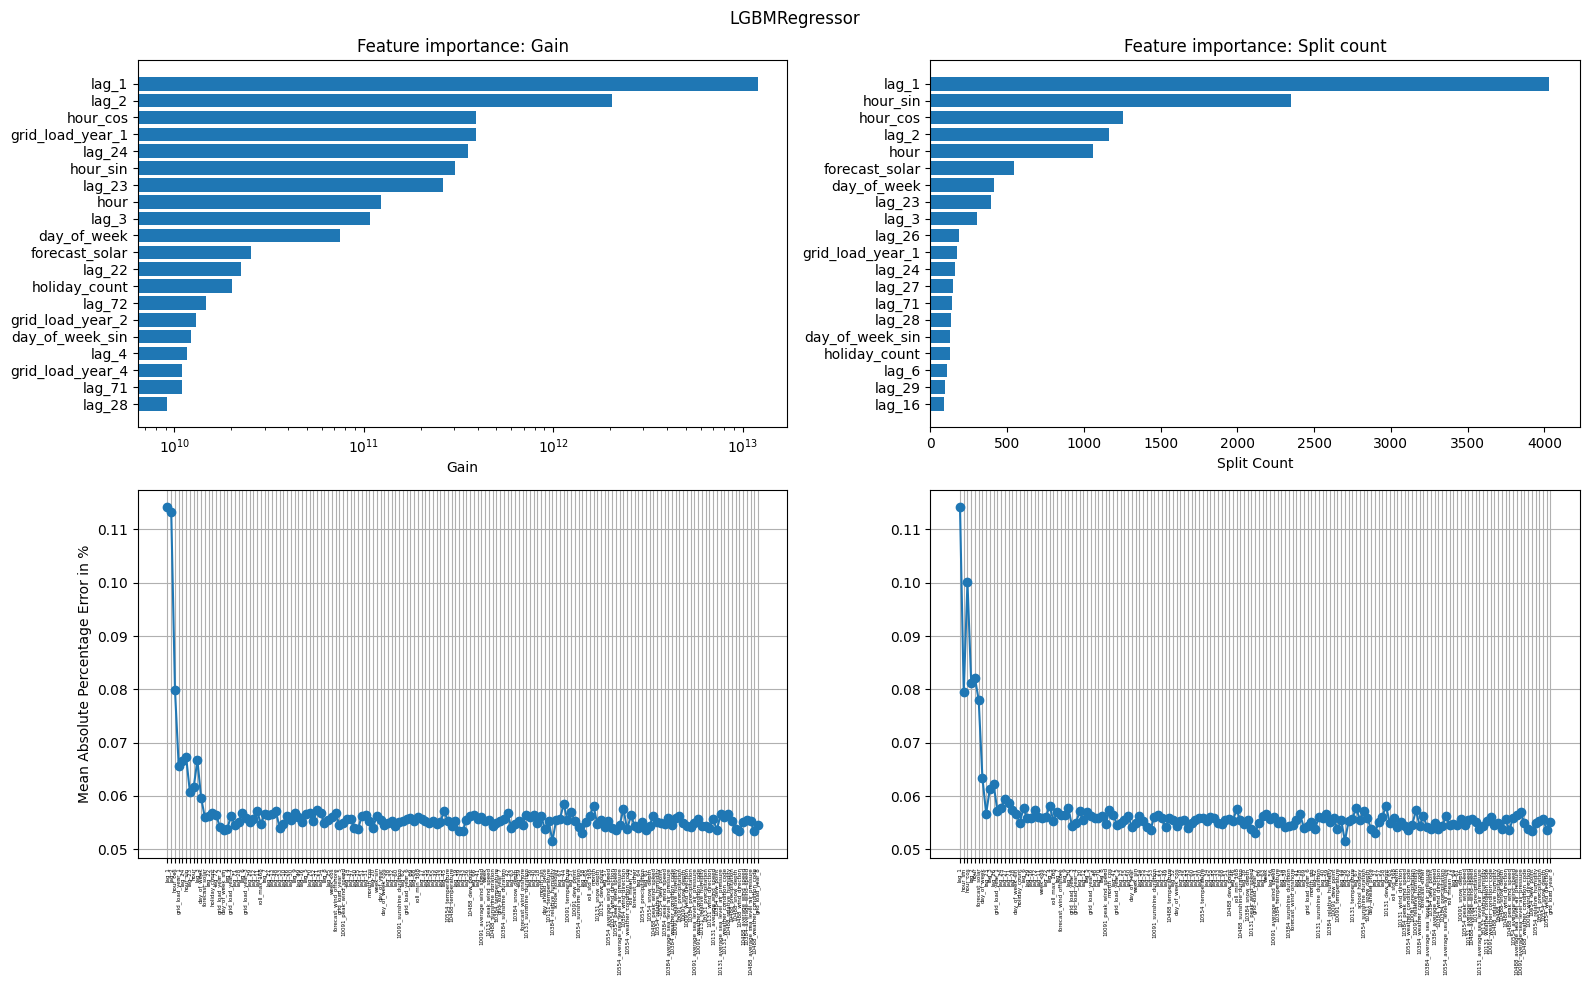

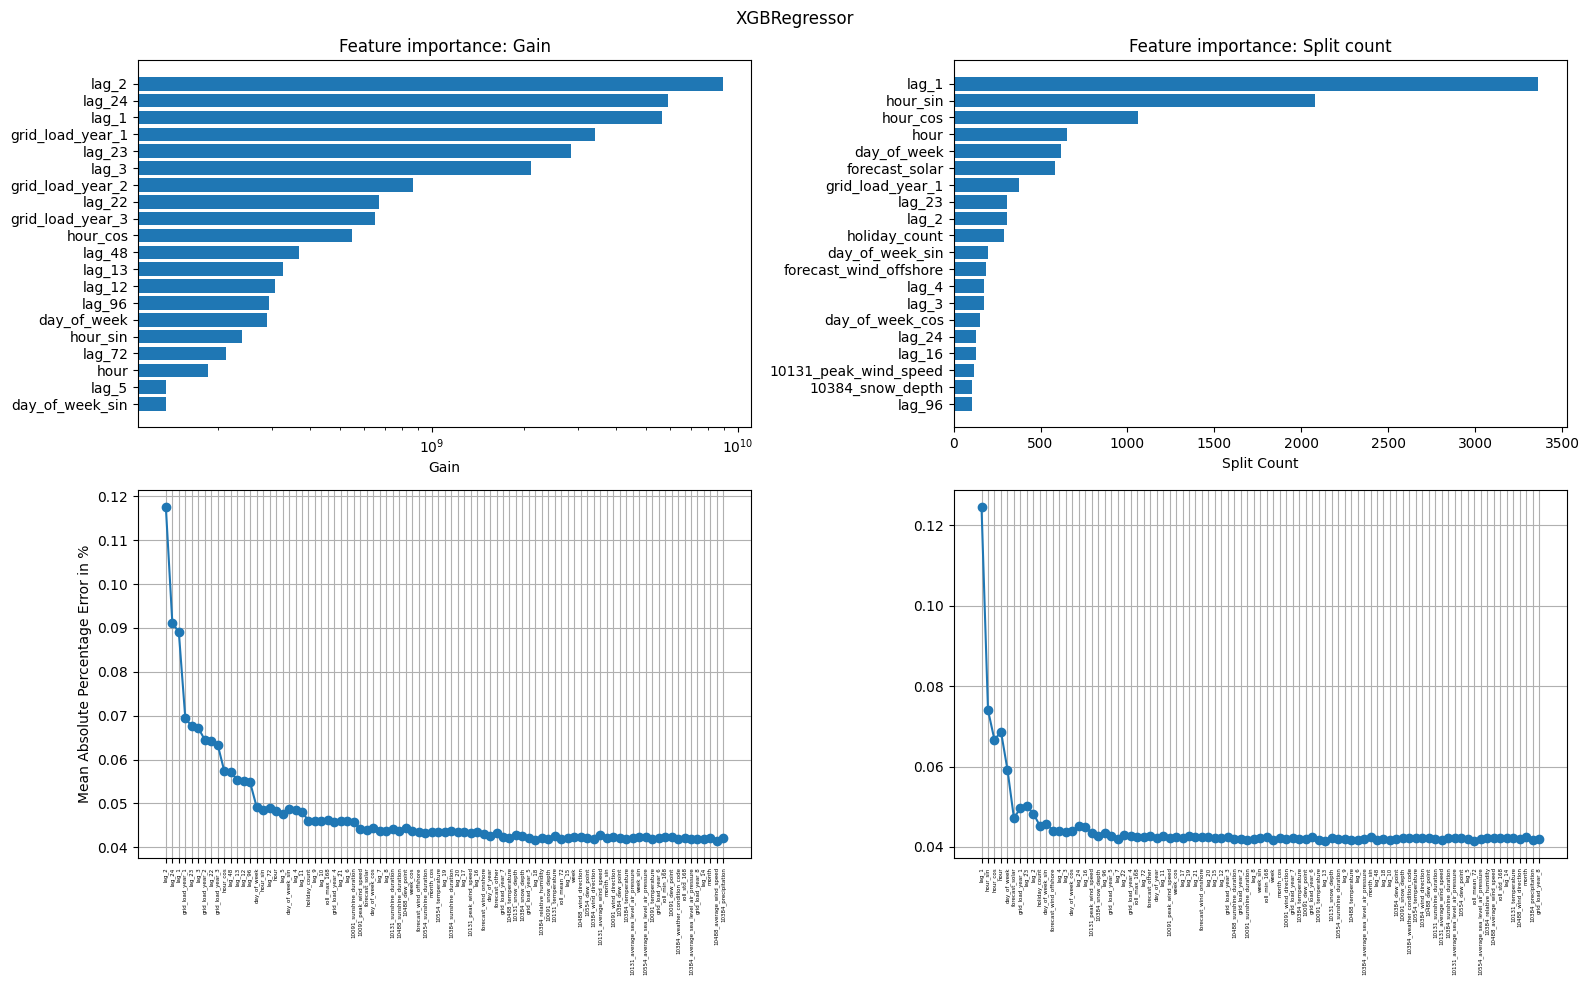

In [22]:
for estimator in ['LGBMRegressor', 'XGBRegressor']:
    imp_gain = pd.read_csv(f'results/explain_model/feature_importance_gain_{estimator}.csv')
    imp_split = pd.read_csv(f'results/explain_model/feature_importance_split_{estimator}.csv')

    imp_gain_flipped = imp_gain.iloc[::-1].reset_index(drop=True)
    imp_split_flipped = imp_split.iloc[::-1].reset_index(drop=True)
    # feature importance
    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    ax[0, 0].barh(imp_gain_flipped.tail(20)["feature"], imp_gain_flipped.tail(20)["importance_gain"])
    ax[0, 0].set_xlabel("Gain")
    ax[0, 0].set_xscale("log")
    ax[0, 0].set_title('Feature importance: Gain')
    ax[0, 1].barh(imp_split_flipped.tail(20)["feature"], imp_split_flipped.tail(20)["importance_split"])
    ax[0, 1].set_xlabel("Split Count")
    ax[0, 1].set_title('Feature importance: Split count')

    # sequential feature importance
    x0 = range(len(imp_gain))
    ax[1, 0].plot(x0, imp_gain['sequential_mape_gain'], marker='o')
    ax[1, 0].set_xticks(x0)
    ax[1, 0].set_xticklabels(imp_gain['feature'], rotation=90, fontsize=4)
    ax[1, 0].set_ylabel('Mean Absolute Percentage Error in %')
    ax[1, 0].grid()
    x1 = range(len(imp_split))
    ax[1, 1].plot(x1, imp_split['sequential_mape_split'], marker='o')
    ax[1, 1].set_xticks(x1)
    ax[1, 1].set_xticklabels(imp_split['feature'], rotation=90, fontsize=4)
    ax[1, 1].grid()

    fig.suptitle(estimator)
    plt.tight_layout()
    plt.show()

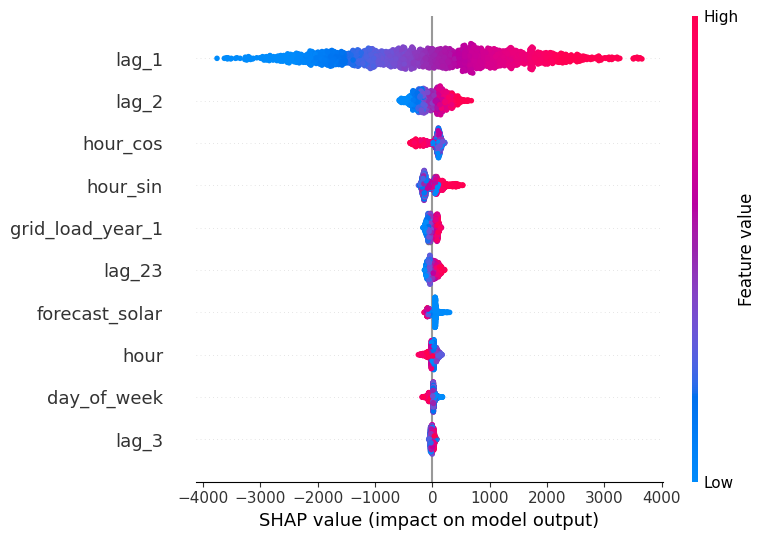

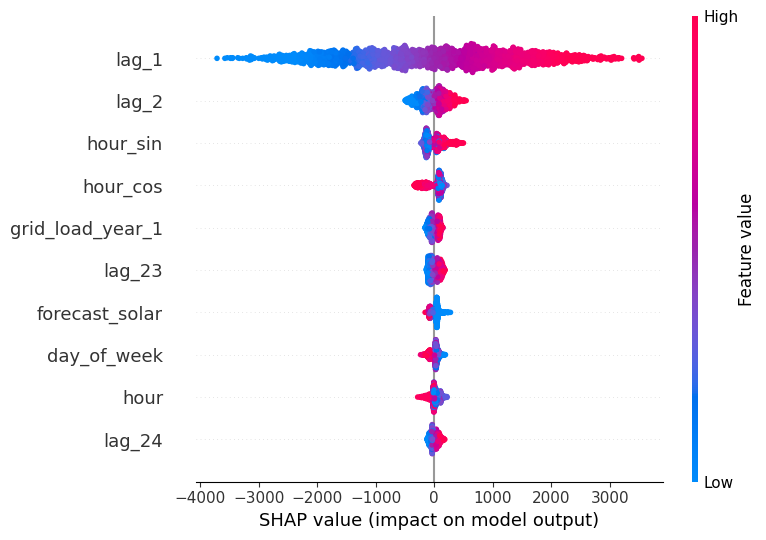

In [23]:
# shap for lgbm
X_train, y_train = forecaster_lgbm.create_train_X_y(y=data_train['grid_load'], exog=data_train.drop(columns=['grid_load']))
forecaster_lgbm.fit(y=data_train['grid_load'], exog=data_train.drop(columns=['grid_load']))
N = min(2000, len(X_train))
features_shap = X_train.sample(n=N, random_state=42)
explainer = shap.TreeExplainer(forecaster_lgbm.estimator)
shap_values = explainer(features_shap)
shap.summary_plot(shap_values, features_shap, max_display=10, show=False)
fig = plt.gcf()
plt.show()

# shap for xgb
X_train, y_train = forecaster_xgb.create_train_X_y(y=data_train['grid_load'], exog=data_train.drop(columns=['grid_load']))
forecaster_xgb.fit(y=data_train['grid_load'], exog=data_train.drop(columns=['grid_load']))
N = min(2000, len(X_train))
features_shap = X_train.sample(n=N, random_state=42)
explainer = shap.TreeExplainer(forecaster_xgb.estimator)
shap_values = explainer(features_shap)
shap.summary_plot(shap_values, features_shap, max_display=10, show=False)
fig = plt.gcf()
plt.show()

### Save Results

In [ ]:
# rename columns for better readability
def rename_cols(col):
    parts = col.replace("_", " ").split()
    result = []
    for p in parts:
        key = p.lower()
        if key in protected_tokens:
            result.append(protected_tokens[key])
        elif key in lower_words:
            result.append(key)
        else:
            result.append(p.capitalize())
    return " ".join(result)

lower_words = {"with", "without", "exogenous"}
protected_tokens = {"lgbmregressor": "LGBMRegressor", "xgbregressor": "XGBRegressor"}
prediction_results = prediction_results.rename(columns=rename_cols)
metrics_results = metrics_results.rename(columns=rename_cols)
metrics_results["Model Name"] = metrics_results["Model Name"].apply(rename_cols)

# save results
prediction_results.to_csv('results/prediction_results.csv', index_label='Datetime')
metrics_results.to_csv('results/metrics_results.csv', index=False)